# Display data

In [2]:
import pandas as pd

#收益率在factors_1d中，事实上不需要从bars_1d中读取
bars_1d = pd.read_parquet('../star_market/bars_1d.parquet')    
bars_1d

factors_1d = pd.read_parquet('../star_market/factors_1d.parquet')
factors_1d

,date,sym,y,return_1day,price_amplitude_2days,high_low_price_amplitude_diff_5days,trade_count_1day,amount_per_trade_5days,turnover_adjusted_by_price_amplitude_1day,big_order_opening_5days,small_order_2days
0,2019-07-22,688001.SH,-0.121982,1.287716,0.584324,0.016029,60408.0,24953.609125,1.210811,0.376324,0.125229
1,2019-07-22,688002.SH,-0.125697,1.510000,0.603187,0.016525,71518.0,26498.377066,1.508671,0.328277,0.126812
2,2019-07-22,688003.SH,-0.145570,0.858824,0.837764,0.015874,69992.0,21372.614599,1.293108,0.233841,0.133100
3,2019-07-22,688005.SH,-0.158086,0.860631,0.666465,0.014166,58696.0,24620.242384,1.407442,0.329050,0.134921
4,2019-07-22,688006.SH,-0.137495,0.991250,0.683083,0.017706,57021.0,25554.279529,1.681472,0.303692,0.124804
...,...,...,...,...,...,...,...,...,...,...,...
556211,2025-07-18,688798.SH,0.013219,0.000000,0.023284,0.000829,3831.0,22695.601983,0.022196,0.199142,0.206725
556212,2025-07-18,688799.SH,0.119649,-0.015313,0.079949,0.004456,12947.0,27488.628213,0.169813,0.250997,0.123998
556213,2025-07-18,688800.SH,0.009454,-0.023654,0.059484,0.002637,22706.0,28293.757190,0.202636,0.291027,0.092957
556214,2025-07-18,688819.SH,0.017210,0.001467,0.020871,0.000937,5464.0,10726.100961,0.027762,0.198714,0.368390


In [3]:
import os, gc, warnings, datetime as dt
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 100)
DATA_DIR   = "../star_market/"   # 原始数据目录

# 训练集和测试集设置
TRAIN_START = "2019-07-22"
TRAIN_END   = "2024-07-22"
TEST_START  = "2024-07-23"
TEST_END    = "2025-07-21"



# ------------------------------------------------------------
# 2. 数据读取
# ------------------------------------------------------------
# 2.1 日线行情（包含开高低收、成交量、成交金额、换手率等）
bars_1d = pd.read_parquet(DATA_DIR + "bars_1d.parquet")  # columns: date,sym,prevclose,open,high,low,close,volume,amount

# 2.2 因子数据
df = pd.read_parquet(DATA_DIR + "factors_1d.parquet")  # columns: date,symbol,factor_name,value


# 3.5 训练/测试划分
train = df[(df["date"] >= TRAIN_START) & (df["date"] <= TRAIN_END)]
test  = df[(df["date"] >= TEST_START) & (df["date"] <= TEST_END)]



# ------------------------------------------------------------
# 4. 模型训练
# ------------------------------------------------------------
X_fields = ['return_1day', 'price_amplitude_2days', 'high_low_price_amplitude_diff_5days', 'trade_count_1day', 'amount_per_trade_5days', 'turnover_adjusted_by_price_amplitude_1day', 'big_order_opening_5days', 'small_order_2days']
X_train = train[X_fields]
y_train = train["y"]

xgb = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.3,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train,y_train)

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)



# ------------------------------------------------------------
# 5. 预测 & 组合构建
# ------------------------------------------------------------
def backtest(model, df):
    df = df.copy()
    df["pred"] = model.predict(df[X_fields])
    # 剔除次日涨停（>19.9%）的极端值
    df = df[df["y"] < 0.199]
    # 每天选预测收益最高的 10 只，等权
    picks = (
        df.groupby("date")
        .apply(lambda x: x.nlargest(10, "pred")[["date", "sym", "y"]])
        .reset_index(drop=True)
    )
    daily_ret = picks.groupby("date")["y"].mean()
    daily_ret.name = "ret"
    return daily_ret

ret_xgb = backtest(xgb, test)
ret_rf  = backtest(rf,  test)



# ------------------------------------------------------------
# 6. 绩效计算
# ------------------------------------------------------------
def performance(ret):
    nav = (1 + ret).cumprod()
    ann_ret = nav.iloc[-1] ** (252 / len(ret)) - 1
    roll_max = nav.cummax()
    drawdown = (nav - roll_max) / roll_max
    max_dd = drawdown.min()
    return nav, ann_ret, max_dd

nav_xgb, ann_xgb, mdd_xgb = performance(ret_xgb)
nav_rf,  ann_rf,  mdd_rf  = performance(ret_rf)

# 基准：STAR 50 指数（000688.SH）
bench = bars_1d[bars_1d["sym"] == "000688.SH"][["date", "close"]].copy()
bench["ret"] = bench["close"].pct_change()
bench = bench[bench["date"].isin(ret_xgb.index)]
bench_nav = (1 + bench["ret"]).cumprod()

# 合并
nav_df = pd.DataFrame({
    "date": ret_xgb.index,
    "nav_xgb": nav_xgb.values,
    "nav_rf": nav_rf.values,
    "index": bench_nav.values,
})
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.set_index("date")



# ------------------------------------------------------------
# 7. 结果打印
# ------------------------------------------------------------
print("XGBoost:")
print(f"  Cumulative Return : {nav_xgb.iloc[-1]-1:.2%}")
print(f"  Annual Return     : {ann_xgb:.2%}")
print(f"  Max Drawdown      : {mdd_xgb:.2%}")

print("\nRandomForest:")
print(f"  Cumulative Return : {nav_rf.iloc[-1]-1:.2%}")
print(f"  Annual Return     : {ann_rf:.2%}")
print(f"  Max Drawdown      : {mdd_rf:.2%}")

# ------------------------------------------------------------
# 8. 保存结果
# ------------------------------------------------------------
nav_df.to_csv("nav_comparison.csv")

XGBoost:
  Cumulative Return : 63.47%
  Annual Return     : 69.01%
  Max Drawdown      : -31.59%

RandomForest:
  Cumulative Return : 63.44%
  Annual Return     : 68.97%
  Max Drawdown      : -27.11%


In [4]:
pd.DataFrame({"feature": X_fields, "xgb_importance": xgb.feature_importances_, "rf_importance": rf.feature_importances_})

,feature,xgb_importance,rf_importance
0,return_1day,0.167907,0.194246
1,price_amplitude_2days,0.149727,0.252805
2,high_low_price_amplitude_diff_5days,0.129473,0.147216
3,trade_count_1day,0.101027,0.047647
4,amount_per_trade_5days,0.131270,0.046829
5,turnover_adjusted_by_price_amplitude_1day,0.116323,0.065910
6,big_order_opening_5days,0.081536,0.042798
7,small_order_2days,0.122738,0.202550



Error Metrics Comparison:
          Model     MSE    RMSE     MAE      R²
0       XGBoost  0.0013  0.0362  0.0237  0.0121
1  RandomForest  0.0013  0.0363  0.0237  0.0050


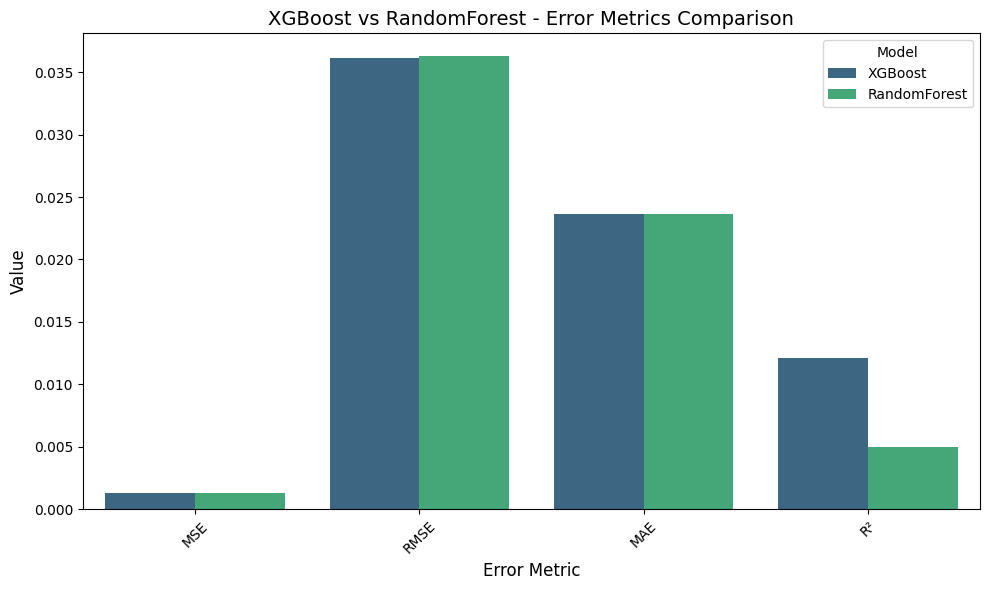

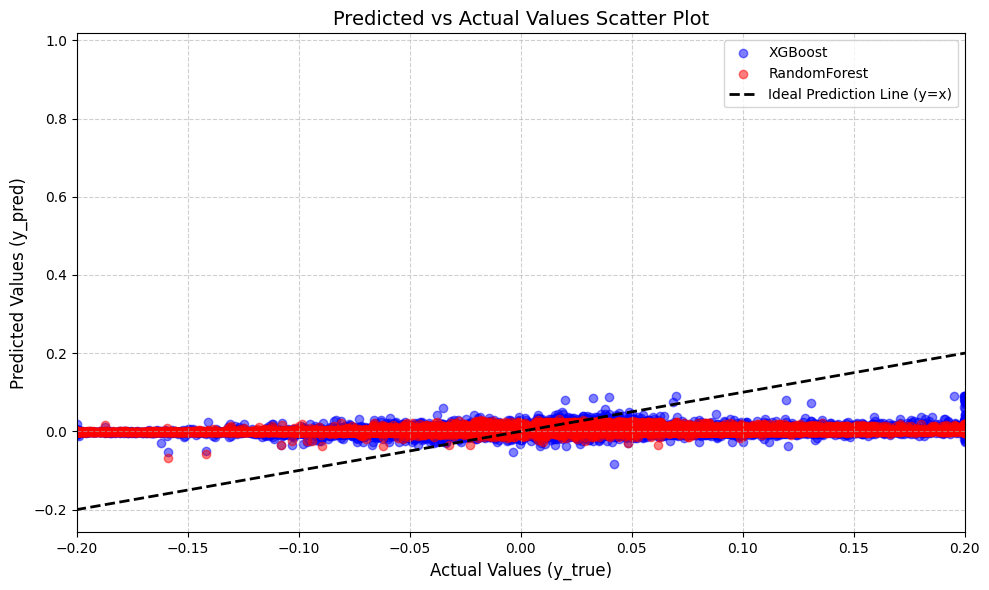

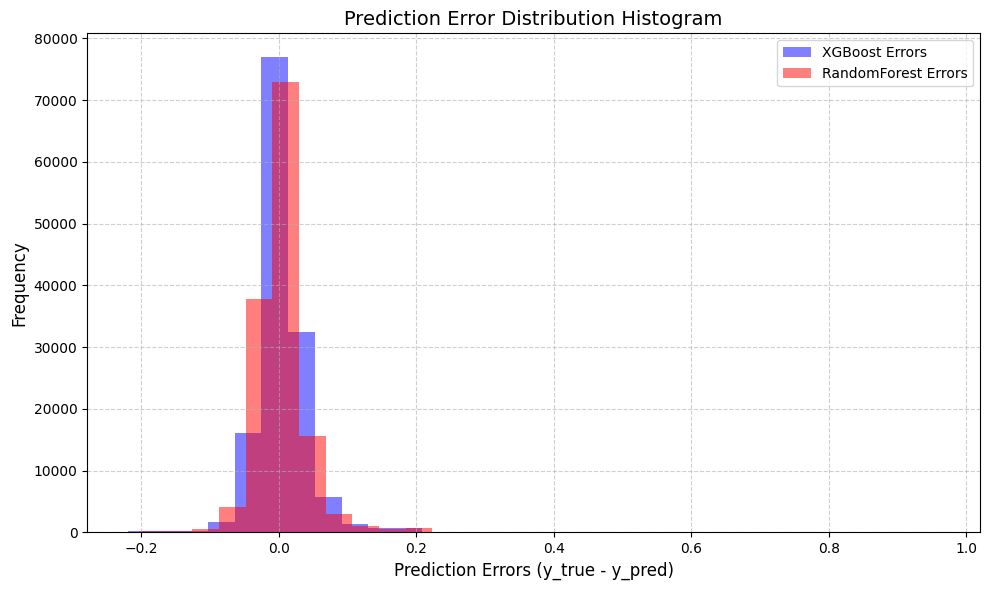

In [5]:
import os, gc, warnings, datetime as dt
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# --------------------------
# 1. Calculate Test Set Predictions and True Values
# --------------------------
X_test = test[X_fields]
y_test = test["y"]

y_pred_xgb = xgb.predict(X_test)
y_pred_rf  = rf.predict(X_test)

# --------------------------
# 2. Calculate Error Metrics
# --------------------------
def calculate_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)  # Use the correct function
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

metrics_xgb = calculate_metrics(y_test, y_pred_xgb, "XGBoost")
metrics_rf  = calculate_metrics(y_test, y_pred_rf,  "RandomForest")

metrics_df = pd.DataFrame([metrics_xgb, metrics_rf])
print("\nError Metrics Comparison:")
print(metrics_df.round(4))

# --------------------------
# 3. Plot Error Metrics Comparison Bar Chart
# --------------------------
plt.figure(figsize=(10, 6))
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')
sns.barplot(data=metrics_melted, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('XGBoost vs RandomForest - Error Metrics Comparison', fontsize=14)
plt.ylabel('Value', fontsize=12)
plt.xlabel('Error Metric', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# --------------------------
# 4. Plot Predicted vs Actual Values Scatter Plot
# --------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label='XGBoost', color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='RandomForest', color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction Line (y=x)')
plt.xlim(-0.2, 0.2)
plt.xlabel('Actual Values (y_true)', fontsize=12)
plt.ylabel('Predicted Values (y_pred)', fontsize=12)
plt.title('Predicted vs Actual Values Scatter Plot', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --------------------------
# 5. Plot Prediction Error Distribution Histogram
# --------------------------
errors_xgb = y_test - y_pred_xgb
errors_rf  = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
plt.hist(errors_xgb, bins=30, alpha=0.5, label='XGBoost Errors', color='blue')
plt.hist(errors_rf, bins=30, alpha=0.5, label='RandomForest Errors', color='red')
plt.xlabel('Prediction Errors (y_true - y_pred)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Error Distribution Histogram', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

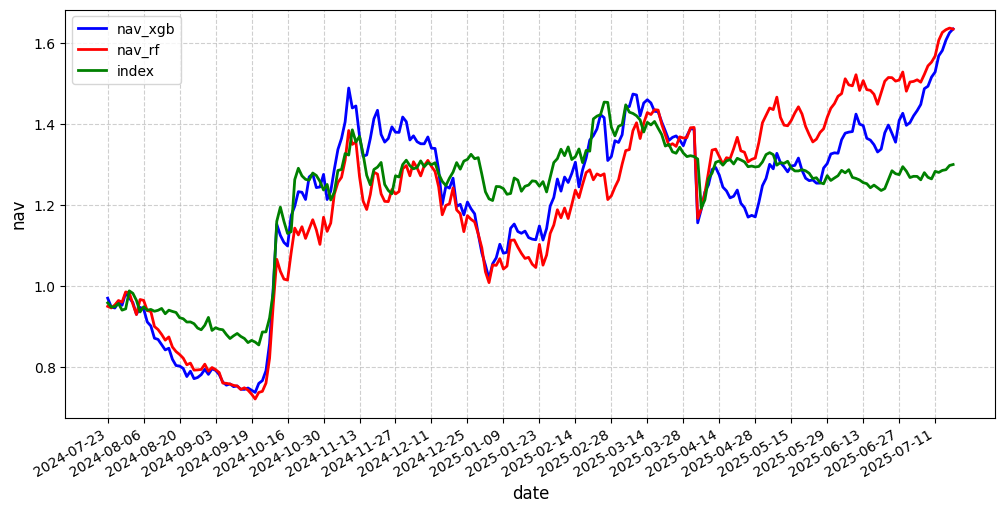

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

df = pd.read_csv('nav_comparison.csv')

# 绘制曲线图
plt.figure(figsize=(12, 6))  # 设置画布大小

# 绘制三条曲线（分别指定颜色和标签）
plt.plot(df['date'], df['nav_xgb'], color='blue', label='nav_xgb',  linewidth=2)
plt.plot(df['date'], df['nav_rf'], color='red', label='nav_rf', linewidth=2)
plt.plot(df['date'], df['index'], color='green',label='index',  linewidth=2)

# 设置图表样式
plt.xlabel('date', fontsize=12)  # 横轴标签
plt.ylabel('nav', fontsize=12)  # 纵轴标签
#plt.title('三条曲线随日期变化图', fontsize=14, pad=20)  # 标题
plt.legend(fontsize=10)  # 显示图例
plt.grid(True, linestyle='--', alpha=0.6)  # 添加网格线（虚线，半透明）

all_dates = df['date']
selected_dates = all_dates[::10]  # 每隔10天取一个日期（如第0,10,20,...天）

# 设置x轴刻度位置和标签
plt.xticks(selected_dates, [date for date in selected_dates], rotation=45)
plt.legend(
    loc='best',       # 图例位置：左上角（可选：'best', 'upper right', 'lower left'等）
    # fontsize=10,            # 字体大小
    # frameon=True,           # 显示图例外框
    # framealpha=0.9,         # 图例外框透明度（0-1）
    # shadow=True,            # 是否显示阴影
    # borderpad=1,            # 图例内边距
    # title='legend',        # 图例标题（可选）
    # title_fontsize=12       # 图例标题字体大小
)
# 优化横轴日期显示（避免重叠）
plt.gcf().autofmt_xdate()  # 自动旋转日期标签


# 显示图表
#plt.tight_layout()  # 自动调整布局
plt.show()


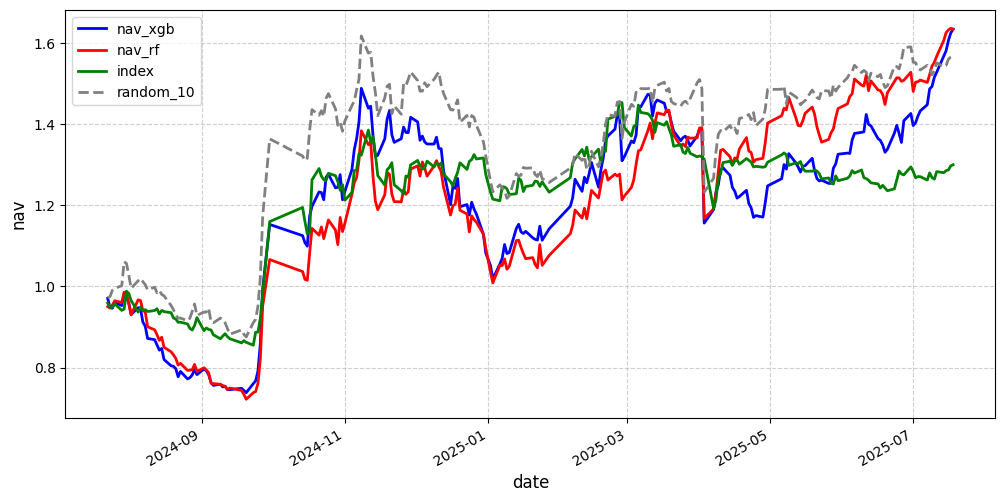

In [11]:
import numpy as np
import time

def random_portfolio(test_df, n=10):
    """
    每天随机选n只股票，等权组合，返回每日收益序列
    随机种子依赖于程序运行时的系统时间（保证每天都不同）
    """
    df = test_df[["date", "sym", "y"]].copy()
    def sample_func(x):
        seed = int(time.time_ns() % (2**32)) + abs(hash(str(x.name)) % (2**32))
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(x), size=min(n, len(x)), replace=False)
        return x.iloc[idx]
    picks = (
        df.groupby("date")
        .apply(sample_func)
        .reset_index(drop=True)
    )
    daily_ret = picks.groupby("date")["y"].mean()
    daily_ret.name = "ret_random"
    return daily_ret


# 生成随机组合每日收益
ret_random = random_portfolio(test, n=10)
nav_random = (1 + ret_random).cumprod()
nav_df["nav_random"] = nav_random.values


# 画图
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(nav_df.index, nav_df["nav_xgb"], color="blue", label="nav_xgb", linewidth=2)
plt.plot(nav_df.index, nav_df["nav_rf"], color="red", label="nav_rf", linewidth=2)
plt.plot(nav_df.index, nav_df["index"], color="green", label="index", linewidth=2)
plt.plot(nav_df.index, nav_df["nav_random"], color="gray", label="random_10", linewidth=2, linestyle="--")

plt.xlabel("date", fontsize=12)
plt.ylabel("nav", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.gcf().autofmt_xdate()
plt.show()